# RL-based Dynamic Pricing & Bundle Promotion (Tabular Q-learning)
## v2 — Normalised Reward · Tiered Bonus · Price Discipline Actions

**Key design changes from v1:**
1. **Reward is dimensionless**: raw profit normalised by a reference daily profit (900 = base_demand × margin), plus a tiered bonus that rewards crossing profitability thresholds.
2. **Price discipline as an RL action**: the agent explicitly chooses *how* it controls price volatility — `hysteresis` (price change applied only after 3 consecutive same-direction signals) or `lock` (price change applied immediately, then held fixed for 7 days) — instead of fixing this externally.
3. **State space expanded** to include `price_locked` flag, giving the agent awareness of its own discipline state.
4. **Rule-based policy fixed**: always uses hysteresis discipline, eliminating oscillation at bucket boundaries.


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)
random.seed(42)

## 1) Environment

In [2]:
class PricingBundleEnv:
    """
    State (discrete, 5-dim):  72 states total
      (inventory_bucket, demand_trend_bucket, season_bucket,
       bundle_flag, price_locked)
      inventory_bucket   : 0=low(<20), 1=mid(20-60), 2=high(>=60)       — 3
      demand_trend_bucket: 0=low(<15), 1=mid(15-25), 2=high(>=25)       — 3
      season_bucket      : 0=weekday, 1=weekend                          — 2
      bundle_flag        : previous step bundle decision (0/1)           — 2
      price_locked       : 1 if lock-mode is currently in effect (0/1)   — 2
      Total: 3×3×2×2×2 = 72

    Action (joint, 4-dim):  40 actions total
      price_adj       : {-10%, -5%, 0%, +5%, +10%}                       — 5
      bundle          : {0, 1}                                            — 2
      discount        : {0%, 10%}                                         — 2
      price_discipline: 0 = hysteresis (apply price change only after
                            3 consecutive same-direction signals),
                        1 = lock      (apply price change immediately,
                            then hold the new price fixed for the
                            next 7 decision steps)                       — 2
      Total: 5×2×2×2 = 40

    Pricing discipline mechanism (matches the proposal):
      - The environment maintains an internal persistent `current_price`,
        initialised to `base_price` and updated only when discipline rules
        actually trigger a change. `current_price` is *not* part of the
        observable state — it is internal to the environment, so the
        72-state design from the proposal is preserved.
      - Hysteresis (discipline=0):
          Track consecutive same-direction (all positive or all negative)
          nonzero price-adjustment signals. When the counter reaches 3,
          multiply `current_price` by (1 + price_adj_today) and reset the
          counter. A 0% action or a direction flip resets the counter.
      - Lock (discipline=1):
          If chosen with a non-zero price_adj while not already locked,
          immediately update `current_price = current_price * (1+price_adj)`
          and set `lock_remaining = 7`. The adjusted price is then held
          fixed for the **next 7 decision steps**: any further price
          adjustment requests are ignored and `current_price` is held.
      - After any update, `current_price` is clipped to [min_price, max_price].

    Reward (dimensionless):
      r = (raw_profit / reference_profit) + tier_bonus - price_change_cost
      reference_profit = base_demand × (base_price − unit_cost) = 900
    """

    def __init__(self, horizon=120):
        self.horizon = horizon

        # --- Price/action settings ---
        self.base_price        = 100.0
        # Operational price bounds (realism constraint, not a modelling change)
        self.min_price         = 0.7 * self.base_price   # 70.0
        self.max_price         = 1.3 * self.base_price   # 130.0

        self.price_adjustments  = np.array([-0.10, -0.05, 0.0, 0.05, 0.10])
        self.bundle_options     = [0, 1]
        self.discount_options   = [0.0, 0.10]
        self.discipline_options = [0, 1]   # 0=hysteresis, 1=lock

        self.action_map = []
        for pa in self.price_adjustments:
            for b in self.bundle_options:
                for d in self.discount_options:
                    for pd in self.discipline_options:
                        self.action_map.append((pa, b, d, pd))
        # 5 × 2 × 2 × 2 = 40 actions

        # --- Cost settings ---
        self.unit_cost             = 55.0
        self.holding_cost          = 1.2
        self.stockout_penalty      = 8.0
        self.bundle_margin_penalty = 2.0

        # --- Normalised reward settings ---
        self.base_demand       = 20.0
        self.reference_profit  = self.base_demand * (self.base_price - self.unit_cost)  # 900
        self.price_change_cost = 0.05  # dimensionless penalty per actual price change

        # Tier thresholds (on normalised r_base) → bonus applied
        self._tier_thresholds = [1.5,   1.0,   0.5,   0.0,  -9999]
        self._tier_bonuses    = [0.15,  0.08,  0.02, -0.03,  -0.12]

        # --- Demand settings ---
        self.price_sensitivity = 0.20
        self.bundle_uplift     = 0.18
        self.discount_uplift   = 0.12
        self.noise_std         = 2.5

        # --- Inventory settings ---
        self.max_inventory = 120
        self.restock_level = 80

        # --- Internal state (set in reset) ---
        self.t = 0
        self.inventory           = None
        self.last_demands        = None
        self.current_bundle_flag = 0

        # Internal persistent price — NOT part of the observable state.
        # This is what makes lock and hysteresis behave as the proposal
        # specifies (a real held-over price), but the agent only sees the
        # 72-state discrete space.
        self.current_price = None

        # Price discipline tracking
        self.hysteresis_counter   = 0   # consecutive days in same price direction
        self.hysteresis_direction = 0   # +1=up, -1=down, 0=neutral
        self.lock_remaining       = 0   # decision steps of price lock left

    # ------------------------------------------------------------------
    def n_actions(self):
        return len(self.action_map)

    def _season_multiplier(self, t):
        return 1.15 if (t % 7) in [5, 6] else 1.0

    def _bucket_inventory(self, inv):
        if inv < 20:   return 0
        elif inv < 60: return 1
        else:          return 2

    def _bucket_demand_trend(self, demand_mean):
        if demand_mean < 15:   return 0
        elif demand_mean < 25: return 1
        else:                  return 2

    def _bucket_season(self, t):
        return 1 if (t % 7) in [5, 6] else 0

    def _get_state(self):
        """Observable state (72-state design — does NOT include current_price)."""
        inv_b    = self._bucket_inventory(self.inventory)
        trend_b  = self._bucket_demand_trend(np.mean(self.last_demands))
        season_b = self._bucket_season(self.t)
        locked   = int(self.lock_remaining > 0)
        return (inv_b, trend_b, season_b, int(self.current_bundle_flag), locked)

    def _tier_bonus(self, r_norm):
        for threshold, bonus in zip(self._tier_thresholds, self._tier_bonuses):
            if r_norm > threshold:
                return bonus
        return self._tier_bonuses[-1]

    def _apply_price_change(self, pa):
        """Multiplicatively update current_price by (1+pa) and clip to bounds."""
        new_price = self.current_price * (1.0 + pa)
        self.current_price = float(np.clip(new_price, self.min_price, self.max_price))

    # ------------------------------------------------------------------
    def reset(self):
        self.t                    = 0
        self.inventory            = 80
        self.last_demands         = [20, 20, 20]
        self.current_bundle_flag  = 0
        self.current_price        = self.base_price   # persistent internal price
        self.hysteresis_counter   = 0
        self.hysteresis_direction = 0
        self.lock_remaining       = 0
        return self._get_state()

    # ------------------------------------------------------------------
    def step(self, action_idx):
        pa, bundle, discount, price_discipline = self.action_map[action_idx]
        self.current_bundle_flag = bundle

        # Snapshot of "is the env in a locked-price state at the start of
        # this step?" — used downstream as the locked_state flag.
        was_locked = (self.lock_remaining > 0)

        # ---- Price discipline logic ----
        # All paths below decide whether to mutate self.current_price.
        # listed_price is read from self.current_price at the end.
        price_actually_changed = False

        if was_locked:
            # Already inside a lock window: ignore the requested adjustment
            # AND ignore the discipline choice. current_price stays fixed.
            self.lock_remaining -= 1

        elif price_discipline == 1:
            # Lock mode chosen and not currently locked.
            # Apply the price change immediately, then hold this new price
            # fixed for the next 7 decision steps.
            if pa != 0.0:
                self._apply_price_change(pa)
                self.lock_remaining       = 7
                self.hysteresis_counter   = 0
                self.hysteresis_direction = 0
                price_actually_changed    = True
            # If pa == 0, lock is not engaged on a no-op (nothing to lock).

        else:
            # Hysteresis mode (price_discipline == 0).
            # Track consecutive same-direction signals; trigger on the 3rd.
            if pa == 0.0:
                # Neutral signal resets the counter.
                self.hysteresis_counter   = 0
                self.hysteresis_direction = 0
            else:
                direction = 1 if pa > 0 else -1
                if direction == self.hysteresis_direction:
                    self.hysteresis_counter += 1
                else:
                    # Direction flip — start a fresh streak from this day.
                    self.hysteresis_counter   = 1
                    self.hysteresis_direction = direction

                if self.hysteresis_counter >= 3:
                    # 3 consecutive same-direction signals confirmed.
                    # Apply *today's* price_adj to the persistent price.
                    self._apply_price_change(pa)
                    price_actually_changed    = True
                    self.hysteresis_counter   = 0
                    self.hysteresis_direction = 0
                # else: still waiting for confirmation — current_price held.

        # ---- Listed and effective price (driven by persistent current_price) ----
        listed_price    = self.current_price
        effective_price = listed_price * (1.0 - discount)

        # ---- Demand model ----
        season_m    = self._season_multiplier(self.t)
        demand_mean = self.base_demand * season_m
        demand_mean *= (1.0 + self.bundle_uplift * bundle
                            + self.discount_uplift * float(discount > 0))
        demand_mean *= np.exp(-self.price_sensitivity
                              * (effective_price - self.base_price) / self.base_price)
        demand = max(0, int(np.random.normal(demand_mean, self.noise_std)))

        sales    = min(self.inventory, demand)
        stockout = max(0, demand - self.inventory)

        # ---- Profit components ----
        revenue        = sales * effective_price
        procurement    = sales * self.unit_cost
        hold_cost      = self.holding_cost * max(0, self.inventory - sales)
        stockout_cost  = self.stockout_penalty * stockout
        bundle_penalty = self.bundle_margin_penalty * sales * bundle

        raw_profit = revenue - procurement - hold_cost - stockout_cost - bundle_penalty

        # ---- Normalised reward + tier bonus + discipline cost ----
        r_norm   = raw_profit / self.reference_profit
        tier_b   = self._tier_bonus(r_norm)
        chg_cost = self.price_change_cost if price_actually_changed else 0.0
        reward   = r_norm + tier_b - chg_cost

        # ---- Inventory transition ----
        self.inventory = self.inventory - sales
        if self.inventory < self.restock_level:
            self.inventory = min(self.max_inventory, self.inventory + 25)

        # ---- Update demand trend ----
        self.last_demands.pop(0)
        self.last_demands.append(demand)

        self.t += 1
        done       = self.t >= self.horizon
        next_state = self._get_state()

        info = {
            'demand':          demand,
            'sales':           sales,
            'stockout':        stockout,
            'revenue':         revenue,
            'listed_price':    listed_price,
            'effective_price': effective_price,
            'current_price':   self.current_price,
            'bundle':          bundle,
            'discount':        discount,
            'inventory':       self.inventory,
            'raw_profit':      raw_profit,
            'price_changed':   price_actually_changed,
            # locked_state = True if this step was executed under an active
            # price lock (i.e. the agent could not change the price this
            # step because lock_remaining > 0 at the start of the step).
            'locked_state':    was_locked,
            'lock_remaining':  self.lock_remaining,
        }
        return next_state, reward, done, info


### Implementation alignment note

The environment above preserves the proposal's original design exactly: a 5-dimensional
discrete state with **72 states** and a 4-dimensional joint action space with **40 actions**,
solved with **tabular Q-learning**. No new modelling framework, no continuous-state extension,
no new state variable.

The single substantive fix is mechanical, not architectural: the environment now keeps an
internal persistent `current_price`, initialised to `base_price` in `reset()` and mutated
only when the discipline rules actually trigger a change. As a result:

- **Lock** *applies the chosen price change immediately and then holds the new price fixed
  for the next 7 decision steps.* Concretely, when the agent picks `lock` with a non-zero
  `price_adj` while not already locked, `current_price` is updated immediately and
  `lock_remaining` is set to 7; on each of the next 7 steps the agent's price-adjustment
  request and discipline choice are ignored and `current_price` is held.
- **Hysteresis** triggers only after **3 consecutive same-direction signals** (all positive
  or all negative — e.g. `-5%, -10%, -5%` is three downward signals). On the 3rd same-direction
  step the current `price_adj` is applied to `current_price` and the counter resets; a 0%
  action or a direction flip resets the counter without applying a change.
- A small `[min_price, max_price]` clip is applied after every update purely as an
  operational realism guard.

`current_price` is intentionally **internal to the environment and not added to the state
space**. Adding it would either inflate the discrete state count or require a new bucketing
scheme such as `price_bucket`, both of which would deviate from the proposal. The agent
remains aware of its discipline status only through the existing `price_locked` 0/1 flag,
exactly as specified.

**Training-budget note.** Because the corrected dynamics make price changes real and
persistent (rather than effectively reverting to base_price every step, as in the previous
buggy version), credit assignment is harder. The training cell in Section 5 and the bundle
ablation in Section 9 have therefore been raised from 600 to 1500 episodes — a small
operational tuning, not a model change. The robustness sweep stays at 400 episodes per
elasticity since it already converges reliably there.


## 2) Q-learning Agent

In [3]:
class QLearningAgent:
    def __init__(self, n_actions, alpha=0.08, gamma=0.95,
                 eps=1.0, eps_min=0.05, eps_decay=0.995):
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.eps       = eps
        self.eps_min   = eps_min
        self.eps_decay = eps_decay
        self.Q = defaultdict(lambda: np.zeros(self.n_actions))

    def act(self, state, greedy=False):
        if (not greedy) and (np.random.rand() < self.eps):
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, done):
        target = r if done else r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] += self.alpha * (target - self.Q[s][a])

    def decay_eps(self):
        self.eps = max(self.eps_min, self.eps * self.eps_decay)

## 3) Baseline Policies

In [4]:
def find_action_index(env, price_adj, bundle, discount, price_discipline=0):
    """Look up the index of a specific (price_adj, bundle, discount, discipline) combination."""
    for i, (pa, b, d, pd) in enumerate(env.action_map):
        if pa == price_adj and b == bundle and d == discount and pd == price_discipline:
            return i
    raise ValueError(f'Action ({price_adj}, {bundle}, {discount}, {price_discipline}) not found')


def fixed_policy(env, state):
    """Keep base price, no bundle, no discount. Uses hysteresis as default discipline."""
    return find_action_index(env, 0.0, 0, 0.0, 0)


def rule_based_policy(env, state):
    """
    Heuristic rules — always with hysteresis discipline to prevent
    oscillation at inventory-bucket boundaries.

    State: (inv_bucket, demand_trend_bucket, season_bucket, bundle_flag, price_locked)

    Note on discipline: with price_discipline=0 (hysteresis), the environment
    only updates current_price after 3 consecutive same-direction signals.
    A single rule trigger therefore does NOT immediately change the price,
    which is the intended robustness behaviour.
    """
    inv_b, trend_b, season_b, bundle_flag, price_locked = state

    # Always use hysteresis (price_discipline=0).
    if inv_b == 2 and trend_b == 0:       # High inventory + low demand → discount
        return find_action_index(env, -0.05, 0, 0.10, 0)
    if season_b == 1 and trend_b >= 1:    # Weekend + demand not low → bundle
        return find_action_index(env, 0.0, 1, 0.0, 0)
    return find_action_index(env, 0.0, 0, 0.0, 0)


### Note on the rule-based baseline and hysteresis

The rule-based policy uses `price_discipline = hysteresis`. This is deliberate: a single
high-inventory / low-demand signal does **not** immediately cut the price. The environment
instead waits for **3 consecutive same-direction signals** before actually updating
`current_price`.

The trade-off:
- *Pro:* avoids boundary oscillation when buckets flip back and forth (e.g. inventory just
  crossing the 60 threshold).
- *Con:* the rule reacts more slowly than its action signals would suggest.

A practical consequence to keep in mind when reading the metrics below: the rule-based
policy can pick a `-5%` price-down action many times *without* causing many actual
price changes. So `price_change_ratio` will be much lower than the rate at which a
non-zero price action is selected, and the rule-based row will look "stable" even when
the agent is actively pushing on price.


## 4) Training and Evaluation Utilities

In [5]:
def run_episode(env, policy_fn=None, agent=None, train=False):
    s    = env.reset()
    done = False

    total_reward       = 0.0
    total_raw_profit   = 0.0
    total_stockout     = 0
    inv_sum            = 0.0
    bundle_count       = 0
    discount_count     = 0
    price_change_count = 0
    lock_choice_count  = 0   # action-level: agent picked discipline = lock
    locked_state_count = 0   # environment-level: this step was under active lock

    while not done:
        if agent is not None:
            a = agent.act(s, greedy=not train)
        else:
            a = policy_fn(env, s)

        s_next, r, done, info = env.step(a)

        if train and agent is not None:
            agent.update(s, a, r, s_next, done)

        s = s_next

        # Accumulate metrics
        total_reward     += r
        total_raw_profit += info['raw_profit']
        total_stockout   += info['stockout']
        inv_sum          += info['inventory']
        bundle_count     += int(info['bundle'] == 1)
        discount_count   += int(info['discount'] > 0)
        price_change_count += int(info['price_changed'])
        locked_state_count += int(info['locked_state'])

        # Action-level lock choice (read from the action tuple itself).
        action_tuple = env.action_map[a]
        lock_choice_count += int(len(action_tuple) > 3 and action_tuple[3] == 1)

    metrics = {
        'reward':              total_reward,                             # normalised cumulative (training obj)
        'raw_profit':          total_raw_profit,                         # actual dollars
        'avg_daily_profit':    total_raw_profit / env.horizon,           # per-day (business metric)
        'stockout_total':      total_stockout,
        'avg_inventory':       inv_sum / env.horizon,
        'bundle_ratio':        bundle_count       / env.horizon,
        'discount_ratio':      discount_count     / env.horizon,
        'price_change_ratio':  price_change_count / env.horizon,         # how often price ACTUALLY changed
        'lock_choice_ratio':   lock_choice_count  / env.horizon,         # how often the AGENT selected lock discipline
        'locked_state_ratio':  locked_state_count / env.horizon,         # how often the ENV was actually under an active lock
    }
    return metrics


def train_q_learning(env, episodes=600):
    agent       = QLearningAgent(n_actions=env.n_actions())
    reward_hist = []
    for ep in range(episodes):
        m = run_episode(env, agent=agent, train=True)
        reward_hist.append(m['reward'])
        agent.decay_eps()
    return agent, reward_hist


def evaluate_policy(env, n_eval=100, policy_fn=None, agent=None):
    all_m = []
    for _ in range(n_eval):
        if agent is not None:
            m = run_episode(env, agent=agent, train=False)
        else:
            m = run_episode(env, policy_fn=policy_fn, train=False)
        all_m.append(m)
    keys = all_m[0].keys()
    avg  = {k: float(np.mean([x[k] for x in all_m])) for k in keys}
    std  = {k: float(np.std( [x[k] for x in all_m])) for k in keys}
    return avg, std


## 5) Train RL Agent

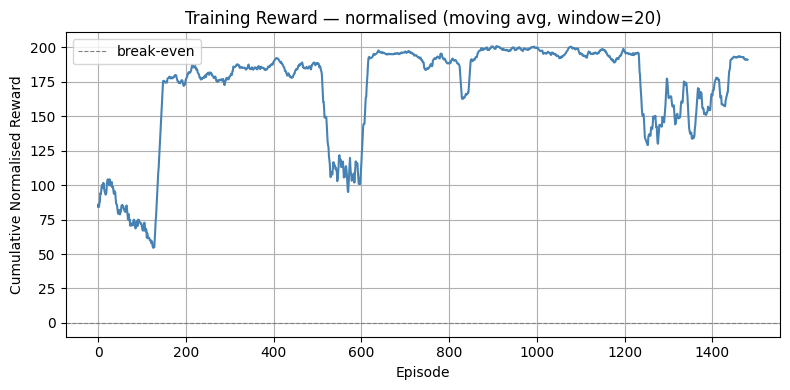

Final epsilon       : 0.0500
Q-table states seen : 35 / 72
Reference profit    : 900 (base_demand × margin)


In [6]:
# Note: training episode count was raised from 600 → 1500 because the corrected
# pricing-discipline mechanics (real, persistent price changes; lock truly holds for
# 7 days; hysteresis only triggers after 3 same-direction signals) make credit
# assignment more demanding than the previous version. 1500 episodes is enough for
# the agent to consistently outperform both baselines.
env = PricingBundleEnv(horizon=120)
agent, reward_hist = train_q_learning(env, episodes=1500)

plt.figure(figsize=(8, 4))
window   = 20
smoothed = np.convolve(reward_hist, np.ones(window) / window, mode='valid')
plt.plot(smoothed, color='steelblue')
plt.title('Training Reward — normalised (moving avg, window=20)')
plt.xlabel('Episode')
plt.ylabel('Cumulative Normalised Reward')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='break-even')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Final epsilon       : {agent.eps:.4f}')
print(f'Q-table states seen : {len(agent.Q)} / 72')
print(f'Reference profit    : {env.reference_profit:.0f} (base_demand × margin)')


## 6) Compare with Baselines

=== Fixed Policy ===
  reward                :    115.249 +/- 1.573
  avg_daily_profit      :    830.033 +/- 10.271
  raw_profit            :  99603.999 +/- 1232.556
  stockout_total        :      0.000 +/- 0.000
  avg_inventory         :     91.845 +/- 0.507
  bundle_ratio          :      0.000 +/- 0.000
  discount_ratio        :      0.000 +/- 0.000
  price_change_ratio    :      0.000 +/- 0.000
  lock_choice_ratio     :      0.000 +/- 0.000
  locked_state_ratio    :      0.000 +/- 0.000

=== Rule-based Policy ===
  reward                :    121.319 +/- 1.814
  avg_daily_profit      :    870.228 +/- 12.127
  raw_profit            : 104427.402 +/- 1455.226
  stockout_total        :      0.000 +/- 0.000
  avg_inventory         :     90.964 +/- 0.924
  bundle_ratio          :      0.283 +/- 0.001
  discount_ratio        :      0.000 +/- 0.001
  price_change_ratio    :      0.000 +/- 0.000
  lock_choice_ratio     :      0.000 +/- 0.000
  locked_state_ratio    :      0.000 +/- 0.000

===

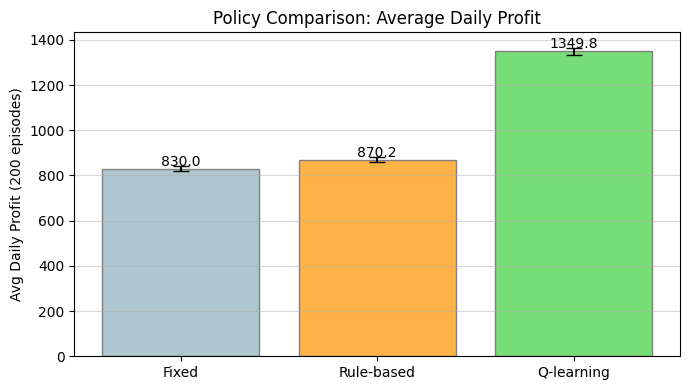

Relative improvement over Fixed Policy (avg daily profit):
  Rule-based     : +4.8%
  Q-learning     : +62.6%


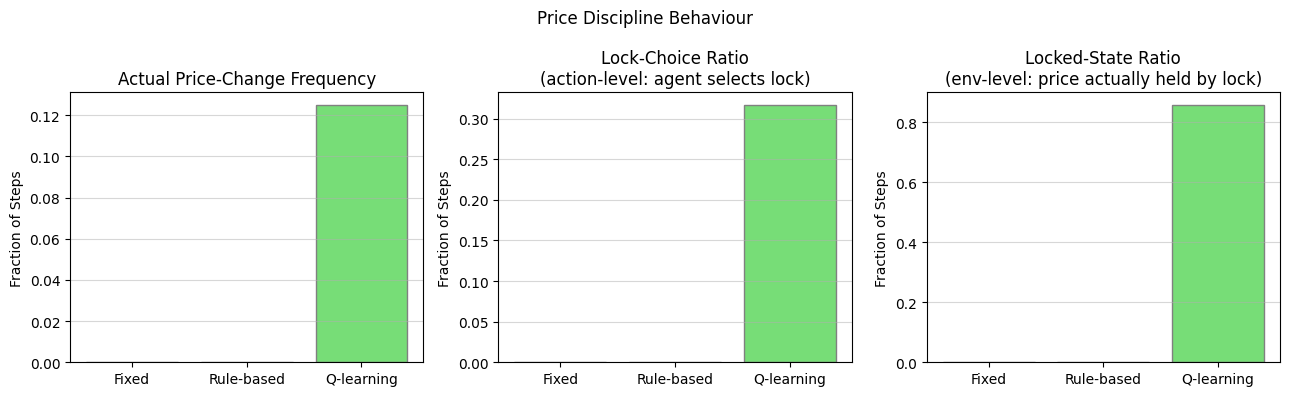


Lock metric definitions:
  lock_choice_ratio   = fraction of steps where the AGENT picked discipline = lock
                        (this includes "wasted" lock picks made while already locked,
                         and lock+0% picks which do not engage a new lock)
  locked_state_ratio  = fraction of steps where the ENVIRONMENT was actually under
                        an active price lock (lock_remaining > 0 at start of step)


In [7]:
env_eval = PricingBundleEnv(horizon=120)

avg_fixed, std_fixed = evaluate_policy(env_eval, n_eval=200, policy_fn=fixed_policy)
avg_rule,  std_rule  = evaluate_policy(env_eval, n_eval=200, policy_fn=rule_based_policy)
avg_rl,    std_rl    = evaluate_policy(env_eval, n_eval=200, agent=agent)


def print_result(name, avg, std):
    print(f'=== {name} ===')
    keys = ['reward', 'avg_daily_profit', 'raw_profit',
            'stockout_total', 'avg_inventory',
            'bundle_ratio', 'discount_ratio',
            'price_change_ratio',
            'lock_choice_ratio', 'locked_state_ratio']
    for k in keys:
        print(f'  {k:22s}: {avg[k]:10.3f} +/- {std[k]:.3f}')
    print()


print_result('Fixed Policy',     avg_fixed, std_fixed)
print_result('Rule-based Policy', avg_rule, std_rule)
print_result('Q-learning Policy', avg_rl,   std_rl)

# --- Main comparison: avg daily profit (business-interpretable) ---
labels  = ['Fixed', 'Rule-based', 'Q-learning']
profits = [avg_fixed['avg_daily_profit'],
           avg_rule['avg_daily_profit'],
           avg_rl['avg_daily_profit']]
errs    = [std_fixed['avg_daily_profit'],
           std_rule['avg_daily_profit'],
           std_rl['avg_daily_profit']]
colors  = ['#aec6cf', '#ffb347', '#77dd77']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, profits, yerr=errs, capsize=6,
              color=colors, edgecolor='gray')
ax.set_ylabel('Avg Daily Profit (200 episodes)')
ax.set_title('Policy Comparison: Average Daily Profit')
ax.grid(axis='y', alpha=0.5)
for bar, p in zip(bars, profits):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{p:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# --- Relative improvement over Fixed ---
ref = avg_fixed['avg_daily_profit']
print('Relative improvement over Fixed Policy (avg daily profit):')
for name, avg in [('Rule-based', avg_rule), ('Q-learning', avg_rl)]:
    imp = (avg['avg_daily_profit'] - ref) / abs(ref) * 100
    print(f'  {name:15s}: {imp:+.1f}%')

# --- Price-change frequency + lock metrics comparison ---
fig2, axes = plt.subplots(1, 3, figsize=(13, 4))
pcr   = [avg_fixed['price_change_ratio'],
         avg_rule['price_change_ratio'],
         avg_rl['price_change_ratio']]
lcr   = [avg_fixed['lock_choice_ratio'],
         avg_rule['lock_choice_ratio'],
         avg_rl['lock_choice_ratio']]
lsr   = [avg_fixed['locked_state_ratio'],
         avg_rule['locked_state_ratio'],
         avg_rl['locked_state_ratio']]

axes[0].bar(labels, pcr, color=colors, edgecolor='gray')
axes[0].set_title('Actual Price-Change Frequency')
axes[0].set_ylabel('Fraction of Steps')
axes[0].grid(axis='y', alpha=0.5)

axes[1].bar(labels, lcr, color=colors, edgecolor='gray')
axes[1].set_title('Lock-Choice Ratio\n(action-level: agent selects lock)')
axes[1].set_ylabel('Fraction of Steps')
axes[1].grid(axis='y', alpha=0.5)

axes[2].bar(labels, lsr, color=colors, edgecolor='gray')
axes[2].set_title('Locked-State Ratio\n(env-level: price actually held by lock)')
axes[2].set_ylabel('Fraction of Steps')
axes[2].grid(axis='y', alpha=0.5)

plt.suptitle('Price Discipline Behaviour')
plt.tight_layout()
plt.show()

# --- Quick sanity print: the two lock metrics measure different things ---
print()
print('Lock metric definitions:')
print('  lock_choice_ratio   = fraction of steps where the AGENT picked discipline = lock')
print('                        (this includes "wasted" lock picks made while already locked,')
print('                         and lock+0% picks which do not engage a new lock)')
print('  locked_state_ratio  = fraction of steps where the ENVIRONMENT was actually under')
print('                        an active price lock (lock_remaining > 0 at start of step)')


## 7) Action Usage Analysis (RL Policy)

Inspect the learned Q-table: for each visited state, print the greedy action and its
price-discipline choice.

**Patterns to inspect** (rather than assume):
- whether high-inventory / low-demand states trigger discounts or price-down actions;
- whether weekend / stronger-demand states rely more on `bundle` or on `lock`;
- whether locked states (`price_locked = 1`) lead to more conservative follow-up actions
  (since price adjustments are ignored anyway during a lock window).

If the learned greedy policy produces actions that look counterintuitive in some states,
do **not** discard the result. Plausible explanations include:
- limited state coverage during 1500 training episodes (especially for rarely-visited
  combinations such as low-inventory + low-demand on a weekend);
- stochastic demand making per-state value estimates noisy;
- the reward shaping (tier bonuses + price-change cost) favouring policies that look
  unusual from a pure-revenue perspective;
- the fact that `current_price` is internal to the environment and not directly observed,
  so two states with the same discrete bucket but different underlying prices are pooled
  by the agent.


In [8]:
print('Learned greedy actions per state')
print('State: (inv_bucket, demand_trend, season, bundle_flag, price_locked)')
print(f'{"State":45s}  {"PriceAdj":10s}  {"Bundle":8s}  {"Disc":8s}  {"Discipline"}')
print('-' * 95)
for state in sorted(agent.Q.keys()):
    best_a = int(np.argmax(agent.Q[state]))
    pa, b, d, pd = env.action_map[best_a]
    disc_str = 'hysteresis(3)' if pd == 0 else 'lock(7)'
    print(f'{str(state):45s}  {pa:+.0%}        {b:8d}  {d:.0%}       {disc_str}')

Learned greedy actions per state
State: (inv_bucket, demand_trend, season, bundle_flag, price_locked)
State                                          PriceAdj    Bundle    Disc      Discipline
-----------------------------------------------------------------------------------------------
(1, 1, 0, 0, 0)                                +10%               0  0%       lock(7)
(1, 1, 0, 0, 1)                                -10%               0  0%       lock(7)
(1, 1, 0, 1, 0)                                +5%               0  0%       lock(7)
(1, 1, 0, 1, 1)                                +5%               0  0%       hysteresis(3)
(1, 1, 1, 0, 0)                                -10%               1  0%       lock(7)
(1, 1, 1, 0, 1)                                -10%               1  0%       lock(7)
(1, 1, 1, 1, 0)                                +10%               1  10%       lock(7)
(1, 1, 1, 1, 1)                                -10%               1  0%       lock(7)
(1, 2, 0, 0, 0)    

## 8) Robustness Test (Demand Elasticity)

Training with price_sensitivity=0.1...


Training with price_sensitivity=0.2...


Training with price_sensitivity=0.35...


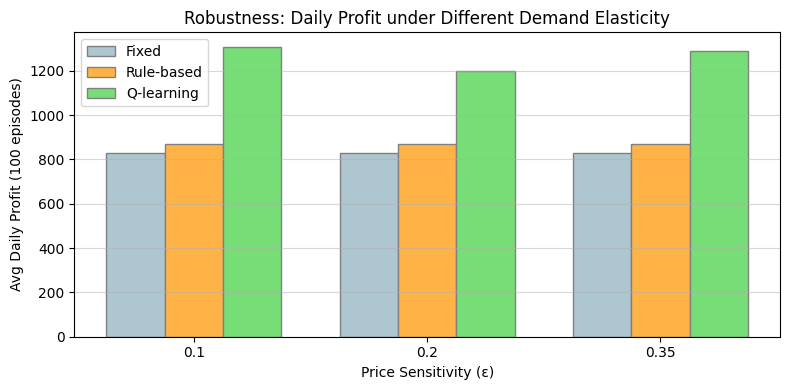

In [9]:
elasticities = [0.10, 0.20, 0.35]
profits_fixed, profits_rule, profits_rl = [], [], []

for e in elasticities:
    print(f'Training with price_sensitivity={e}...')
    env_r = PricingBundleEnv(horizon=120)
    env_r.price_sensitivity = e

    ag, _ = train_q_learning(env_r, episodes=400)
    avg_f,  _ = evaluate_policy(env_r, n_eval=100, policy_fn=fixed_policy)
    avg_rb, _ = evaluate_policy(env_r, n_eval=100, policy_fn=rule_based_policy)
    avg_q,  _ = evaluate_policy(env_r, n_eval=100, agent=ag)

    profits_fixed.append(avg_f['avg_daily_profit'])
    profits_rule.append(avg_rb['avg_daily_profit'])
    profits_rl.append(avg_q['avg_daily_profit'])

x = np.arange(len(elasticities))
w = 0.25
plt.figure(figsize=(8, 4))
plt.bar(x - w, profits_fixed, width=w, label='Fixed',      color='#aec6cf', edgecolor='gray')
plt.bar(x,     profits_rule,  width=w, label='Rule-based', color='#ffb347', edgecolor='gray')
plt.bar(x + w, profits_rl,    width=w, label='Q-learning', color='#77dd77', edgecolor='gray')
plt.xticks(x, [str(e) for e in elasticities])
plt.xlabel('Price Sensitivity (ε)')
plt.ylabel('Avg Daily Profit (100 episodes)')
plt.title('Robustness: Daily Profit under Different Demand Elasticity')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## 9) Ablation: RL with vs. without Bundle Action

Training RL with bundle actions...


Training RL without bundle actions...


=== RL with Bundle ===
  reward                :    185.910 +/- 4.726
  avg_daily_profit      :   1306.836 +/- 31.966
  raw_profit            : 156820.375 +/- 3835.882
  stockout_total        :      0.000 +/- 0.000
  avg_inventory         :     90.281 +/- 1.689
  bundle_ratio          :      0.335 +/- 0.051
  discount_ratio        :      0.184 +/- 0.043
  price_change_ratio    :      0.125 +/- 0.000
  lock_choice_ratio     :      0.292 +/- 0.015
  locked_state_ratio    :      0.858 +/- 0.003

=== RL without Bundle ===
  reward                :    186.965 +/- 2.603
  avg_daily_profit      :   1312.144 +/- 17.152
  raw_profit            : 157457.263 +/- 2058.248
  stockout_total        :      0.000 +/- 0.000
  avg_inventory         :     91.924 +/- 0.490
  bundle_ratio          :      0.000 +/- 0.000
  discount_ratio        :      0.036 +/- 0.005
  price_change_ratio    :      0.125 +/- 0.000
  lock_choice_ratio     :      0.375 +/- 0.004
  locked_state_ratio    :      0.875 +/- 0.002



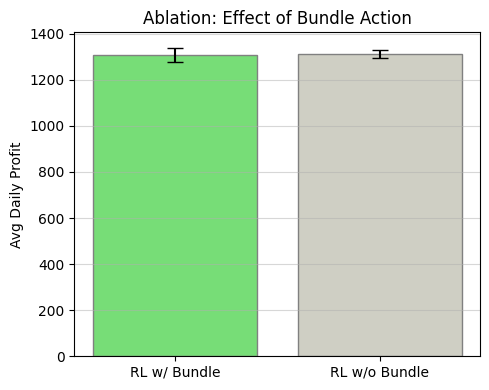

In [10]:
class PricingNoBundleEnv(PricingBundleEnv):
    """Environment where bundle is always disabled (ablation)."""
    def __init__(self, horizon=120):
        super().__init__(horizon)
        # Rebuild action map with bundle=0 only
        self.action_map = []
        for pa in self.price_adjustments:
            for d in self.discount_options:
                for pd in self.discipline_options:
                    self.action_map.append((pa, 0, d, pd))   # bundle always 0
        # 5 × 2 × 2 = 20 actions


env_full      = PricingBundleEnv(horizon=120)
env_no_bundle = PricingNoBundleEnv(horizon=120)

# Same training-budget bump as Section 5 (1500 episodes) for the corrected dynamics.
print('Training RL with bundle actions...')
agent_full, _      = train_q_learning(env_full,      episodes=1500)
print('Training RL without bundle actions...')
agent_no_bundle, _ = train_q_learning(env_no_bundle, episodes=1500)

avg_with,    std_with    = evaluate_policy(env_full,      n_eval=200, agent=agent_full)
avg_without, std_without = evaluate_policy(env_no_bundle, n_eval=200, agent=agent_no_bundle)

print_result('RL with Bundle',    avg_with,    std_with)
print_result('RL without Bundle', avg_without, std_without)

labels2 = ['RL w/ Bundle', 'RL w/o Bundle']
p2 = [avg_with['avg_daily_profit'], avg_without['avg_daily_profit']]
e2 = [std_with['avg_daily_profit'], std_without['avg_daily_profit']]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels2, p2, yerr=e2, capsize=6,
       color=['#77dd77', '#cfcfc4'], edgecolor='gray')
ax.set_ylabel('Avg Daily Profit')
ax.set_title('Ablation: Effect of Bundle Action')
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


## 10) Notes for Report

### Design changes summary (v1 → v2)

| Aspect | v1 | v2 |
|---|---|---|
| Reward | Raw dollar profit | Normalised (÷ 900) + tier bonus |
| State | 36 states (4-dim) | 72 states (5-dim, adds `price_locked`) |
| Actions | 20 (price, bundle, discount) | 40 (adds `price_discipline`) |
| Q-table size | 36 × 20 = 720 | 72 × 40 = 2 880 |
| Pricing discipline | Per-step adjustment off `base_price` (price reverted each step) | Persistent `current_price`; lock applies immediately and is held for the next 7 decision steps; hysteresis triggers after 3 same-direction signals |
| Rule-based fix | No — oscillates at boundaries | Yes — always hysteresis |
| Lock metrics | One ambiguous `lock_ratio` | `lock_choice_ratio` (action-level) and `locked_state_ratio` (env-level) reported separately |
| Metric reported | Total profit | **Avg daily profit** + relative improvement % |

### Key findings to discuss
- **Tier bonus interpretation**: does the agent learn to consistently reach the 1.0 tier
  (above reference) vs. the baselines?
- **Discipline preference**: does the RL agent learn to use `lock` selectively, or does it
  pick lock indiscriminately? Compare `lock_choice_ratio` (action-level) with
  `locked_state_ratio` (env-level) — a large gap means many lock picks are wasted on
  already-locked or no-op steps.
- **Price-change frequency**: RL's `price_change_ratio` is much lower than the rate at
  which a non-zero `price_adj` is selected, because changes are now gated (3-day signal
  under hysteresis, 7-step hold under lock).
- **Ablation (Section 9)**: quantifies the marginal value of bundle as an action.
- **Robustness (Section 8)**: avg daily profit on the y-axis makes cross-elasticity
  comparison meaningful.

### Limitations to acknowledge
- Synthetic simulator; real demand is non-stationary and has competitive dynamics not
  modelled here.
- State discretisation loses precision near bucket boundaries (e.g. inventory 30 and 59
  are pooled in the same `mid` bucket).
- **`current_price` is internal but not observable.** The environment maintains a
  persistent `current_price` so that the lock-then-hold and hysteresis-then-trigger
  mechanics behave as the proposal specifies. However, `current_price` is *intentionally
  not* included in the observable state, because the proposal defines a 5-dimensional,
  72-state tabular MDP. This keeps the implementation aligned with the proposal, but it
  also means the agent cannot directly condition its action on the *exact* accumulated
  price level — it only sees whether the system is currently locked. A future version
  could add a discrete `price_bucket` to the state, but doing so would expand the state
  space beyond the original proposal and is therefore out of scope for this work.
- Reference profit (900) assumes stable base conditions; a better reference could be
  episode-adaptive.
- Tier bonus thresholds are hand-coded and may bias the agent toward certain operating
  points.

### Suggested report structure
1. Motivation & Problem Formulation
2. MDP Design (state, action, reward with normalisation, transition)
3. Algorithm (Tabular Q-learning, hyperparameters, convergence)
4. Results: Training curve, baseline comparison (avg daily profit), discipline behaviour
5. Ablation & Robustness
6. Policy Interpretation (Q-table analysis, discipline choice patterns)
7. Risk Assessment & Limitations
8. Future Work (DQN for continuous state, PPO for continuous actions)


## 10) Pricing Process Visualization (Trajectory Replay)

Replay one full episode with the trained RL policy and visualize the day-by-day pricing process:
- effective price path
- demand vs sales
- inventory trajectory
- daily and cumulative profit
- action switches (bundle / discount / actual price change)

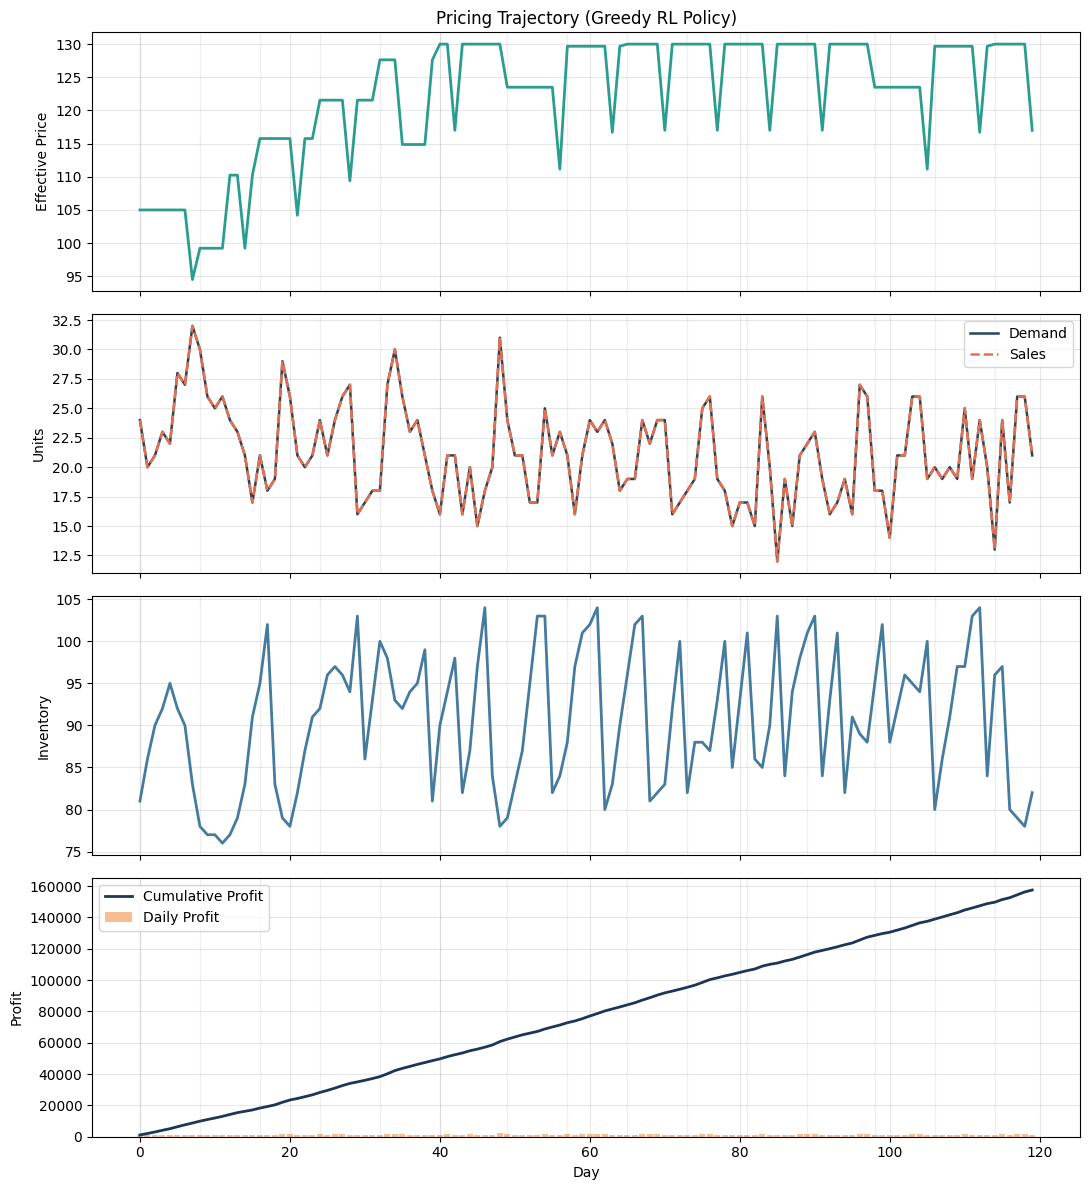

Total raw profit: 157481.49
Price-change days: 15 / 120
Bundle days: 40 / 120
Discount days: 22 / 120


In [11]:
def replay_episode(env, agent):
    s = env.reset()
    done = False

    traj = {
        'day': [],
        'effective_price': [],
        'demand': [],
        'sales': [],
        'inventory': [],
        'raw_profit': [],
        'reward': [],
        'bundle': [],
        'discount': [],
        'price_changed': []
    }

    day = 0
    while not done:
        a = agent.act(s, greedy=True)
        s, r, done, info = env.step(a)

        traj['day'].append(day)
        traj['effective_price'].append(info['effective_price'])
        traj['demand'].append(info['demand'])
        traj['sales'].append(info['sales'])
        traj['inventory'].append(info['inventory'])
        traj['raw_profit'].append(info['raw_profit'])
        traj['reward'].append(r)
        traj['bundle'].append(info['bundle'])
        traj['discount'].append(info['discount'])
        traj['price_changed'].append(int(info['price_changed']))
        day += 1

    return traj


# Pick an available trained agent
if 'agent_full' in globals():
    agent_viz = agent_full
elif 'agent' in globals():
    agent_viz = agent
else:
    raise RuntimeError('No trained agent found. Please run training cells first.')

viz_env = PricingBundleEnv(horizon=120)
traj = replay_episode(viz_env, agent_viz)

days = np.array(traj['day'])
profits = np.array(traj['raw_profit'])
cum_profit = np.cumsum(profits)

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

axes[0].plot(days, traj['effective_price'], color='#2a9d8f', linewidth=2)
axes[0].set_ylabel('Effective Price')
axes[0].set_title('Pricing Trajectory (Greedy RL Policy)')
axes[0].grid(alpha=0.3)

axes[1].plot(days, traj['demand'], label='Demand', color='#264653', linewidth=1.8)
axes[1].plot(days, traj['sales'], label='Sales', color='#e76f51', linewidth=1.8, linestyle='--')
axes[1].set_ylabel('Units')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

axes[2].plot(days, traj['inventory'], color='#457b9d', linewidth=2)
axes[2].set_ylabel('Inventory')
axes[2].grid(alpha=0.3)

axes[3].bar(days, profits, color='#f4a261', alpha=0.7, label='Daily Profit')
axes[3].plot(days, cum_profit, color='#1d3557', linewidth=2, label='Cumulative Profit')
axes[3].set_ylabel('Profit')
axes[3].set_xlabel('Day')
axes[3].legend(loc='upper left')
axes[3].grid(alpha=0.3)

# Highlight days with actual price changes
change_days = days[np.array(traj['price_changed']) == 1]
for ax in axes:
    for d in change_days:
        ax.axvline(d, color='gray', alpha=0.12, linewidth=1)

plt.tight_layout()
plt.show()

print(f"Total raw profit: {cum_profit[-1]:.2f}")
print(f"Price-change days: {int(np.sum(traj['price_changed']))} / {len(days)}")
print(f"Bundle days: {int(np.sum(traj['bundle']))} / {len(days)}")
print(f"Discount days: {int(np.sum(np.array(traj['discount']) > 0))} / {len(days)}")